## Assignments

<b> 8/1 Implement and test Milstein scheme <b>

a, Implement the Milstein method in the MCMethod class's evolve_simulated_spot method, test it by pricing an option with it and compare the PV with analytic (7p)

b, Compare the strong convergence of Euler and Milstein methods as we reduce the size of timesteps. (8p)
    
   - The strong convergence error with timestep dt is measured as the expected pathwise abolute error at time T between the approximation and exact solution. 
   $ \epsilon^{strong}(dt) = E[|S^{approx, dt}(T) - S^{exact}(T)|] $

In [20]:
import os 
import sys

sys.path.append("..\..\..")

from src.pricer import *
MarketData.initialize()

In [21]:
und = Stock.TEST_COMPANY
ls = LongShort.LONG
strike = 1.2
expiry = 1
strike_level = strike * MarketData.get_spot()[und]

model = FlatVolModel(und)

In [22]:
contract_opt = EuropeanContract(und, PutCallFwd.PUT, ls, strike_level, expiry)
pricer_opt_an = EuropeanAnalyticPricer(contract_opt, model, Params())

In [23]:
mc_params = MCParams(num_of_path=10000,
                     tenor_frequency=4,
                     antithetic=False,
                     standardize=False,
                     control_variate=False,
                     seed=1,
                     evolve_spot_method=MCNumMethod.MILSTEIN)

pricer_opt_mc = GenericMCPricer(contract_opt, model, mc_params)

In [24]:
fv_opt_an = pricer_opt_an.calc_fair_value()
fv_opt_mc_m = pricer_opt_mc.calc_fair_value_with_ci()

print("OPTION AN: " + str(fv_opt_an))
print("OPTION MC Milstein: " + str(fv_opt_mc_m))

OPTION AN: 20.594305984211573
OPTION MC Milstein: (20.29064539408366, (19.92719467893637, 20.654096109230952))


In [35]:
frequencies = [2**i for i in range(1, 6)]

In [36]:
strong_conv_error_euler = np.zeros(len(frequencies))
strong_conv_error_milstein = np.zeros(len(frequencies))
for i in range(0, len(frequencies)):
    pricer_opt_mc.params.tenor_frequency = frequencies[i]
    pricer_opt_mc.params.evolve_spot_method = MCNumMethod.EXACT
    exact = pricer_opt_mc.mc_method.simulate_spot_paths()
    
    pricer_opt_mc.params.evolve_spot_method = MCNumMethod.EULER
    approx_euler = pricer_opt_mc.mc_method.simulate_spot_paths()
    strong_conv_error_euler[i] = np.mean(np.abs(approx_euler - exact))
    
    pricer_opt_mc.params.evolve_spot_method = MCNumMethod.MILSTEIN
    approx_milstein = pricer_opt_mc.mc_method.simulate_spot_paths()
    strong_conv_error_milstein[i] = np.mean(np.abs(approx_milstein - exact))

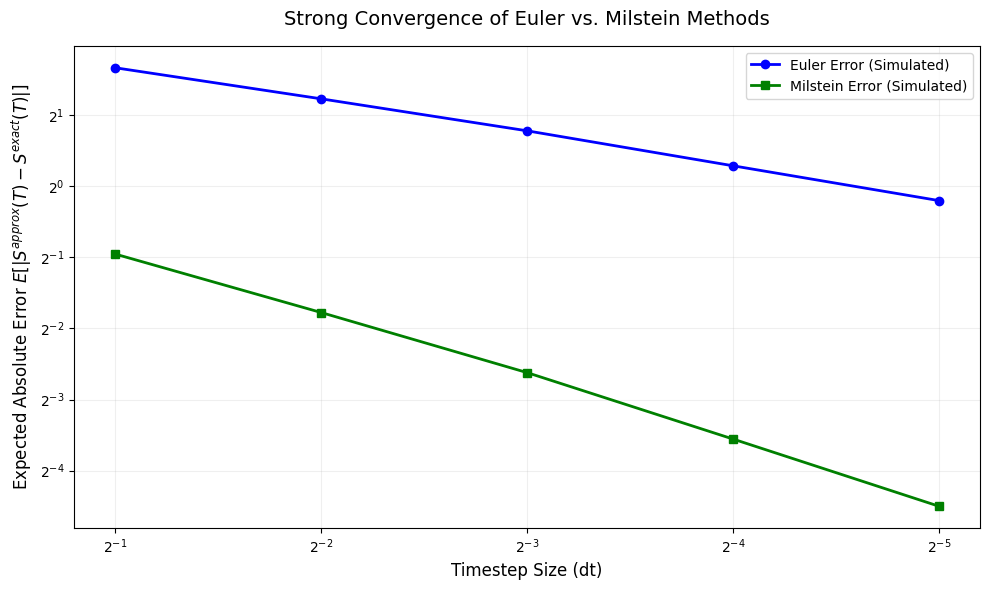

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate dt values from your frequencies
dt_values = 1.0 / np.array(frequencies)

plt.figure(figsize=(10, 6))

# 1. Plot the actual simulated errors
plt.loglog(dt_values, strong_conv_error_euler, 
           marker='o', color='blue', label='Euler Error (Simulated)', linewidth=2, base=2)
plt.loglog(dt_values, strong_conv_error_milstein, 
           marker='s', color='green', label='Milstein Error (Simulated)', linewidth=2, base=2)

# 3. Formatting to make it neat
plt.title('Strong Convergence of Euler vs. Milstein Methods', fontsize=14, pad=15)
plt.xlabel('Timestep Size (dt)', fontsize=12)
plt.ylabel('Expected Absolute Error $E[|S^{approx}(T) - S^{exact}(T)|]$', fontsize=12)

# Invert x-axis so smaller dt (higher frequency) is on the right, showing convergence
plt.gca().invert_xaxis() 

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(fontsize=10, loc='best')
plt.tight_layout()

# Show the plot
plt.show()

In [38]:
local_order_euler = np.log2(strong_conv_error_euler[:-1] / strong_conv_error_euler[1:])
local_order_milstein = np.log2(strong_conv_error_milstein[:-1] / strong_conv_error_milstein[1:])

print("Local Euler Orders:", local_order_euler)
print("Local Milstein Orders:", local_order_milstein)

Local Euler Orders: [0.43682345 0.44978698 0.49190576 0.489555  ]
Local Milstein Orders: [0.82188281 0.84505294 0.9341879  0.94499997]
